In [1]:
# Data manipulation and numerical computation
import numpy as np
import pandas as pd
import os

# pandas all columns display
pd.set_option('display.max_columns', None)

# Load data

In [2]:
# before: path = "../../data/processed/"
path = "data/processed"

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

df_copy = df.copy()

end_idx = df.columns.get_loc("Watershed")
new_cols = df.columns[: end_idx + 1]

# Keep until Watershed
df = df.loc[:, new_cols].copy()
df = df.drop(columns=['CodeSite_SamplingOperations_x', 'Watershed'])

# add the ibd column
df['IBD'] = df_copy['IBD']
df

SamplingOperations_code Date_SamplingOperation  \
2703       S02115200_20070702             2007-07-02   
33984      S05218450_20070709             2007-07-09   
33929      S05217350_20070709             2007-07-09   
48228      S05235850_20070709             2007-07-09   
35408      S05234290_20070709             2007-07-09   
...                       ...                    ...   
42720      S06580577_20230907             2023-09-07   
35760      S06001284_20230907             2023-09-07   
35783      S06001533_20230907             2023-09-07   
38878      S06137040_20231011             2023-10-11   
38873      S06137014_20231011             2023-10-11   

       TotalAbundance_SamplingOperation  Achaa01  Achac01  Achaf01  Achaf02  \
2703                                400      NaN      NaN      NaN      NaN   
33984                               400      NaN      NaN     12.5      NaN   
33929                               400      NaN      NaN      NaN      NaN   
48228                               400      NaN      NaN      2.5      NaN   
35408                               400      NaN      NaN      7.5      NaN   
...                                 ...      ...      ...      ...      ...   
42720                               426      NaN      NaN      NaN      NaN   
35760                               421      NaN      NaN      NaN      NaN   
35783                               401      NaN      NaN      NaN      NaN   
38878                               400      NaN      NaN      NaN      NaN   
38873                               405      NaN      NaN      NaN      NaN   

       Achal01  Acham01  Achan01  Achat01    Achat02  Achat03  Achba01  \
2703       NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN   5.000000      NaN      NaN   
48228      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
35408      NaN      NaN      NaN      NaN  20.000000      NaN      NaN   
...        ...      ...      ...      ...        ...      ...      ...   
42720      NaN      NaN      NaN      NaN   4.694836      NaN      NaN   
35760      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN  14.962594      NaN      NaN   
38878      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
38873      NaN      NaN      NaN      NaN  69.135802      NaN      NaN   

       Achbi01  Achbi02  Achbr01  Achca01  Achca02  Achca03  Achca04  Achch01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

       Achcl01  Achco01  Achco02  Achco03  Achco04  Achcr01  Achcy01  Achda01  \
2703       NaN      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      2.5   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...    

In [3]:
achat = df_copy[df_copy[['Achat01', 'Achat02', 'Achat03']].notnull().all(axis=1)]
achat

,SamplingOperations_code,CodeSite_SamplingOperations_x,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaa01,Achac01,Achaf01,Achaf02,Achal01,Acham01,Achan01,Achat01,Achat02,Achat03,Achba01,Achbi01,Achbi02,Achbr01,Achca01,Achca02,Achca03,Achca04,Achch01,Achcl01,Achco01,Achco02,Achco03,Achco04,Achcr01,Achcy01,Achda01,Achda02,Achde01,Achde02,Achde03,Achdi01,Achdi02,Achdr01,Achel01,Achen01,Acheu01,Achex01,Achex02,Achex03,Achfl01,Achfr01,Achfu01,Achge01,Achgr01,Achgr02,Achgr03,Achha01,Achhe01,Achhi01,Achho01,Achho02,Achho03,Achhu01,Achim01,Achim02,Achim03,Achin01,Achin02,Achja01,Achja02,Achjo01,Achko01,Achkr01,Achkr02,Achkr03,Achkr04,Achku01,Achla01,Achla02,Achla03,Achla04,Achla05,Achla06,Achle01,Achle02,Achli01,Achli02,Achli03,Achli04,Achlo01,Achlu01,Achlu02,Achma01,Achmi01,Achmi02,Achmi03,Achmo01,Achmo02,Achna01,Achna02,Achne01,Achni01,Achno01,Achob01,Achpa01,Achpe01,Achpe02,Achpf01,Achpl01,Achpo01,Achpr01,Achpr02,Achps01,Achps02,Achps03,Achps04,Achpu01,Achpy01,Achre01,Achri01,Achro01,Achro02,Achro03,Achro04,Achru01,Achru02,Achsa01,Achsc01,Achse01,Achse02,Achsi01,Achst01,Achst02,Achst03,Achst04,Achsu01,Achsu02,Achsu03,Achsu04,Achsu05,Achsu06,Achsu07,Achte01,Achth01,Achtr01,Achtr02,Achtr03,Achtu01,Achzh01,Achzi01,Actde01,Actno01,Actro01,Actse01,Actsp01,Actsu01,Actvu01,Adlaq01,Adlba01,Adlbr01,Adlbr02,Adlmi01,Adlmu01,Adlmu02,Adlpa01,Adlsu01,Afrre01,Ampae01,Ampaf01,Ampal01,Ampat01,Ampbi01,Ampbu01,Ampco01,Ampcu01,Ampde01,Ampdi01,Ampdi02,Ampdu01,Ampei01,Ampex01,Ampfo01,Ampfo02,Amphe01,Amphi01,Ampin01,Ampin02,Ampli01,Ampma01,Ampme01,Ampmi01,Ampmi02,Ampmo01,Ampne01,Ampne02,Ampno01,Ampol01,Ampov01,Amppa01,Amppe01,Amppe02,Amppo01,Amppo02,Amppr01,Ampps01,Ampri01,Ampst01,Ampst02,Ampsu01,Ampsu02,Ampsu03,Ampsu04,Amptu01,Ampve01,Ampve02,Ampvi01,Anaba01,Anemi01,Anetu01,Anoeu01,Anoga01,Anoin01,Anosp01,Astfo01,Aulal01,Aulam01,Aulbr01,Aulcr01,Aulcr02,Auldi01,Aulgr01,Aulis01,Aulit01,Aulli01,Aulni01,Aulpa01,Aulps01,Aulps02,Aulsu01,Aulsu02,Aulte01,Aulva01,Azpno01,Bacci01,Bacpa01,Bacul01,Berru01,Bible01,Birbi01,Brabr01,Braca01,Brali01,Brane01,Brane02,Brapr01,Braps01,Breke01,Calae01,Calae02,Calal01,Calau01,Calba01,Calbi01,Calfa01,Calfo01,Calfo02,Calhy01,Calla01,Calla02,Calla03,Calle01,Calmi01,Calpa01,Calpu01,Calsc01,Calsi01,Caltr01,Calve01,Calwe01,Camcy01,Camhi01,Capcr01,Catad01,Cavpa01,Cenre01,Cergr01,Chaal01,Chabe01,Chafa01,Chamu01,Chare01,Charh01,Chasc01,Chath01,Clico01,Cliin01,Cocbr01,Cocca01,Coccl01,Cocco01,Cocde01,Cocdi01,Cocdi02,Coceu01,Cocgr01,Cochu01,Cochu02,Cocin01,Cocla01,Cocle01,Cocli01,Cocme01,Cocne01,Cocne02,Cocne03,Cocpa01,Cocpe01,Cocpl01,Cocps01,Cocps02,Cocre01,Cocro01,Cocsc01,Cocse01,Cocsu01,Conwe01,Cosco01,Cosla01,Cosla02,Craac01,Craac02,Craha01,Crari01,Crasu01,Crasv01,Cravi01,Crazi01,Creru01,Creth01,Ctepu01,Cycat01,Cycbo01,Cycco01,Cyccy01,Cycde01,Cycde02,Cycdi01,Cycdu01,Cycex01,Cycgl01,Cycir01,Cyckr01,Cycku01,Cycme01,Cycme02,Cycmi01,Cycop01,Cycpl01,Cycpl02,Cycps01,Cycsc01,Cycsc02,Cycst01,Cycst02,Cycst03,Cycst04,Cycsu01,Cycth01,Cycwo01,Cylgr01,Cymaf01,Cymaf02,Cymal01,Cymal02,Cymam01,Cyman01,Cyman02,Cyman03,Cyman04,Cymap01,Cymas01,Cymbe01,Cymbi01,Cymbr01,Cymbu01,Cymci01,Cymco01,Cymcu01,Cymcy01,Cymdi01,Cymdo01,Cymeh01,Cymel01,Cymel02,Cymex01,Cymex02,Cymex03,Cymfl01,Cymfr01,Cymga01,Cymhe01,Cymhe02,Cymhu01,Cymin01,Cymin02,Cymin03,Cymka01,Cymko01,Cymku01,Cymla01,Cymla02,Cymla03,Cymlu01,Cymma01,Cymme01,Cymme02,Cymmi01,Cymna01,Cymna02,Cymne01,Cymne02,Cymne03,Cymob01,Cymob02,Cympa01,Cympe01,Cympe02,Cympl01,Cympr01,Cympr02,Cympr03,Cympu01,Cymre01,Cymrh01,Cymru01,Cymsi01,Cymsi02,Cymsi03,Cymso01,Cymsp01,Cymst01,Cymsu01,Cymsu02,Cymsu03,Cymsu04,Cymsu05,Cymsu06,Cymsu07,Cymsu08,Cymsu09,Cymtr01,Cymtr02,Cymtu01,Cymtu02,Cymtu03,Cymtu04,Cymve01,Cymvu01,Delal01,Delap01,Delco01,Delde01,Delde02,Delkr01,Delve01,Dener01,Denfr01,Denku01,Denpa01,Dense01,Densu01,Densu02,Denta01,Dente01,Diabi01,Diaco01,Diade01,Diaeh01,Diaga01,Diahy01,Diame01,Diamo01,Diapa01,Diapr01,Diapy01,Diate01,Diate02,Diavi01,Diavu01,Dicda01,Didge01,Dimna01,Dipab01,Dipae01,Dipbo01,D

They are **different species** with **different ecology**, so their IBD calibrations typically differ. Do **not** collapse them for official IBD; for ML, collapse only if validated on held-out sites.

* **Achnanthes coarctata**: aerophilic, often on wet moss/rocks; distinct habitat signal. ([Diatoms.org][1])
* **Achnanthes conspicua**: now **Platessa conspicua** (reclassified), so collapsing by the “Achco” stem mixes genera. ([Diatoms.org][2])
* **Achnanthes convergens**: reported as prevalent and adaptable in rivers, implying a different tolerance profile. ([MDPI][3])

If you lack the s,v table, assume they are not interchangeable. Collapse only if genus weight is small and grouped-CV shows unchanged MAE after merging.

[1]: https://diatoms.org/species/47801/achnanthes_coarctata?utm_source=chatgpt.com "Achnanthes coarctata | Species"
[2]: https://diatoms.org/genera/platessa/guide?utm_source=chatgpt.com "Guide to Platessa | Genera"
[3]: https://www.mdpi.com/2073-4441/14/6/956?utm_source=chatgpt.com "A Case Study in the Han River, South Korea"


# Knwon NaN values percentage per column

In [4]:
# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

In [5]:
# keep the columns with less than 99% NaN 
df = df.loc[:, df.isnull().mean() < 0.99]

# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

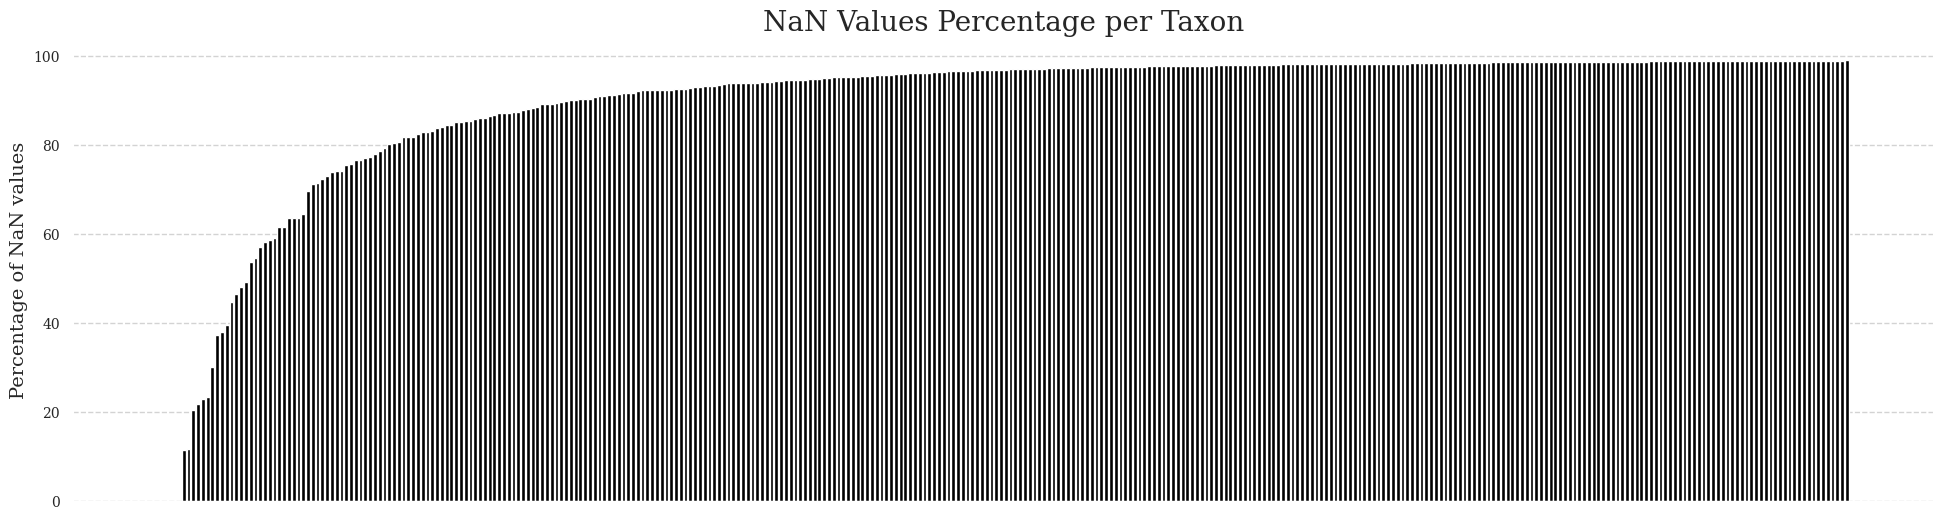

In [6]:
# Create a plot of NaN percentages per column
import matplotlib.pyplot as plt

# restart matplotlib
from scripts import style
style.mpl_apply()

plt.figure(figsize=(24, 6))
plt.bar(vals.index, vals.values, color='black')
plt.xticks(rotation=90)
plt.ylabel('Percentage of NaN values')
plt.title('NaN Values Percentage per Taxon')
# dont show x axis labels
plt.xticks([])
plt.show()


In [7]:
# display some rows
pd.set_option("display.max_columns", 8)
df

,SamplingOperations_code,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
2703,S02115200_20070702,2007-07-02,400,NaN,...,NaN,902925.0,6941112.0,10.5
33984,S05218450_20070709,2007-07-09,400,NaN,...,NaN,442885.0,6199880.0,20.0
33929,S05217350_20070709,2007-07-09,400,NaN,...,NaN,442250.0,6218040.0,20.0
48228,S05235850_20070709,2007-07-09,400,NaN,...,2.500000,463192.0,6225280.0,NaN
35408,S05234290_20070709,2007-07-09,400,NaN,...,10.000000,456573.0,6224410.0,16.6
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,2023-09-07,426,NaN,...,4.694836,908596.0,6499943.0,14.5
35760,S06001284_20230907,2023-09-07,421,NaN,...,87.885986,910629.0,6500149.0,16.3
35783,S06001533_20230907,2023-09-07,401,NaN,...,62.344140,909322.0,6499820.0,14.8
38878,S06137040_20231011,2023-10-11,400,NaN,...,10.000000,967828.0,6518569.0,20.0


In [8]:
# select the desired columns correctly using a list of column names
ibd = df[['SamplingOperations_code', 'Date_SamplingOperation', 'Longitude_Lambert93', 'Latitude_Lambert93', 'IBD']]
ibd = ibd.set_index('SamplingOperations_code', inplace=False)
ibd

,Date_SamplingOperation,Longitude_Lambert93,Latitude_Lambert93,IBD
SamplingOperations_code,,,,
S02115200_20070702,2007-07-02,902925.0,6941112.0,10.5
S05218450_20070709,2007-07-09,442885.0,6199880.0,20.0
S05217350_20070709,2007-07-09,442250.0,6218040.0,20.0
S05235850_20070709,2007-07-09,463192.0,6225280.0,NaN
S05234290_20070709,2007-07-09,456573.0,6224410.0,16.6
...,...,...,...,...
S06580577_20230907,2023-09-07,908596.0,6499943.0,14.5
S06001284_20230907,2023-09-07,910629.0,6500149.0,16.3
S06001533_20230907,2023-09-07,909322.0,6499820.0,14.8


# No tengo 40 GB de RAM para correr esto

In [ ]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# --------- helpers ---------
def days(dt): return np.asarray(pd.to_datetime(dt), 'datetime64[D]').astype('int64')

def estimate_alpha(x, y, t_days):
    # spatial range ≈ median 5-NN distance; temporal range ≈ median gap
    P = np.c_[x, y]
    nn = NearestNeighbors(n_neighbors=6).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]             # 5 NNs
    r_s = np.median(d)                                           # meters
    gaps = np.diff(np.sort(np.unique(t_days)))*360               # the samples are usually taken in years
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0     # days
    return (r_s / r_t)**2

def robust_alpha_from_design(df):
    """ Estimate robust spatio-temporal scaling alpha from data DataFrame, if, e.g., many NaN.
        df must have columns Longitude_Lambert93, Latitude_Lambert93, Date_SamplingOperation.
    """
    # spatial median 5-NN distance
    P = df[["Longitude_Lambert93","Latitude_Lambert93"]].to_numpy()
    nn = NearestNeighbors(n_neighbors=6).fit(P)
    d = nn.kneighbors(return_distance=True)[0][:,1:]   # 5 nearest
    r_s = np.median(d)

    # temporal median per-site gap (days), independent of IBD NaNs
    g = (df.assign(t=pd.to_datetime(df["Date_SamplingOperation"]).values.astype("datetime64[D]").astype(int))
            .reset_index()[["SamplingOperations_code","t"]])
    # site code = text before last '_' in SamplingOperations_code
    sites = g["SamplingOperations_code"].str.rsplit('_', n=1, regex=False).str[0]
    g["site"] = sites
    gaps = (g.sort_values(["site","t"])
              .groupby("site")["t"]
              .apply(lambda v: np.diff(v.unique())))
    r_t = np.median(np.concatenate([a[a>0] for a in gaps.values if a.size>0])) if len(gaps) else 1.0

    return (r_s / max(r_t,1.0))**2

def kernel(dist, kind="gaussian", eps=None):
    # dist >= 0; eps is a scale. Default: median neighbor distance.
    if eps is None: eps = np.median(dist[dist>0]) if np.any(dist>0) else 1.0
    u = dist / eps
    if kind == "gaussian":      return np.exp(-(u**2))
    if kind == "multiquadric":  return np.sqrt(1.0 + u**2)
    if kind == "imq":           return 1.0 / np.sqrt(1.0 + u**2)
    if kind == "linear":        return np.maximum(1.0 - u, 0.0)
    raise ValueError("unknown kernel")

def build_st_index(x, y, t_days, alpha):
    tz = np.sqrt(alpha) * t_days
    Z  = np.c_[x, y, tz]
    nbrs = NearestNeighbors(n_neighbors=64, algorithm="auto").fit(Z)
    return nbrs

def predict_st_kernel(x, y, t_days, z,
                      xq, yq, tq_days,
                      alpha, k=64, kind="gaussian", eps=None, min_pts=8):
    # training index
    nbrs = build_st_index(x, y, t_days, alpha)
    tqz  = np.sqrt(alpha) * tq_days
    Zq   = np.c_[xq, yq, tqz]
    # kNN in space–time
    dist, idx = nbrs.kneighbors(Zq, n_neighbors=k, return_distance=True)
    # kernel weights and predictions
    w = kernel(dist, kind=kind, eps=eps)
    # guard: if too few neighbors or all weights tiny, fall back to inverse distance
    wsum = w.sum(1)
    bad  = (wsum <= 1e-12)
    if np.any(bad):
        w[bad] = 1.0 / (dist[bad] + 1e-6)
        wsum[bad] = w[bad].sum(1)
    y_nei = z[idx]
    return (w * y_nei).sum(1) / wsum

# --------- main driver for your df ---------
def interpolate_ibd_daily(ibd_df, k=64, kernel_kind="gaussian", eps=None,
                          sites="unique"):
    df = ibd_df.copy()
    df["t"] = days(df["Date_SamplingOperation"])
    df = df.sort_values("t")
    # training data (drop NaN IBD)
    tr = df.loc[df["IBD"].notna(), ["Longitude_Lambert93","Latitude_Lambert93","t","IBD"]].to_numpy()
    x, y, t, z = tr[:,0], tr[:,1], tr[:,2], tr[:,3]
    # alpha from data
    alpha = estimate_alpha(x, y, t)
    # query sites
    if sites == "unique":
        sites_xy = df[["Longitude_Lambert93","Latitude_Lambert93"]].drop_duplicates().to_numpy()
    elif isinstance(sites, np.ndarray):
        sites_xy = sites
    else:
        raise ValueError("sites must be 'unique' or an array of shape (m,2)")
    # daily timeline
    tmin, tmax = int(df["t"].min()), int(df["t"].max())
    Tq = np.arange(tmin, tmax + 1, dtype=int)
    # cartesian product of sites × days
    Xq = np.repeat(sites_xy[:,0], len(Tq))
    Yq = np.repeat(sites_xy[:,1], len(Tq))
    TQ = np.tile(Tq, len(sites_xy))
    # predict
    Zq = predict_st_kernel(x, y, t, z, Xq, Yq, TQ, alpha, k=k, kind=kernel_kind, eps=eps)
    # package result
    out = pd.DataFrame({
        "Longitude_Lambert93": Xq,
        "Latitude_Lambert93":  Yq,
        "Date_SamplingOperation": pd.to_datetime(TQ, unit="D"),
        "IBD_hat": Zq
    })
    return out, alpha

In [10]:
# ---- usage ----
# ibd is your DataFrame indexed by SamplingOperations_code
# out_df, alpha = interpolate_ibd_daily(ibd, k=64, kernel_kind="gaussian")
# out_df has one interpolated IBD per unique site per day across the observed date range.

# Lo hago para un dia

In [51]:
# This function converts datetime to integer days
def _days(dt): return np.asarray(pd.to_datetime(dt), 'datetime64[D]').astype('int64')

# This function estimates the alpha parameter for space-time interpolation
# the alpha parameter balances spatial and temporal distances
# for example, if alpha is large, temporal distances are more important
# if alpha is small, spatial distances are more important
def _estimate_alpha(x, y, t_days):
    # let P be the spatial points
    # the function c_[x,y] concatenates x and y as columns
    P = np.c_[x,y]
    # let nn be the nearest neighbors model
    # the nn connects each point to its 6 nearest neighbors

    nn = NearestNeighbors(n_neighbors=6).fit(P)
    # let r_s be the median spatial distance between neighbors
    # the function kneighbors returns the distances and indices of the neighbors
    # the median spatial distance is literaly the median of the distances to the nearest neighbors
    # we ignore the first column (distance to itself, which is zero)
    r_s = np.median(nn.kneighbors(return_distance=True)[0][:,1:])

    # let gaps be the sorted unique time differences between observations
    # the function np.diff computes the n-th discrete difference along the given axis
    gaps = np.diff(np.sort(np.unique(t_days))) * 360  # the samples are usually taken in years
    # let r_t be the median temporal gap between observations
    # we consider only positive gaps (greater than zero)
    r_t = np.median(gaps[gaps>0]) if np.any(gaps>0) else 1.0       # days
    # return the ratio of squared spatial and temporal distances
    # if alpha is gratert than 1, spatial distances are more important
    # if alpha is less than 1, temporal distances are more important
    # the importance is measured by the distance of influence
    # for example, if alpha is 4, spatial distances have 4 times more influence than temporal distances, this could because the phenomenon being modeled is more spatially correlated than temporally correlated, because it changes slowly over time or there not are many observations over time
    return (r_s / r_t)**2

def _kernel(d, eps=None):
    # let d be the distances
    # let eps be the bandwidth parameter
    if eps is None: eps = np.median(d[d>0]) if np.any(d>0) else 1.0
    u = d / eps
    return np.exp(-(u*u))  # Gaussian

# build the nearest neighbors index for space-time points
# it is called an index because it allows to quickly find the nearest neighbors of a point
def _build_index(x,y,t,alpha):
    # the third dimension is scaled by sqrt(alpha)*t because we want to balance spatial and temporal distances
    Z = np.c_[x, y, np.sqrt(alpha)*t]
    return NearestNeighbors(n_neighbors=64).fit(Z)

def st_predict_grid(x,y,t,z, alpha, xg, yg, tq_days, k=64, eps=None):
    # neighbors in (x,y, sqrt(alpha)*t)
    nbrs = _build_index(x,y,t,alpha)
    # XQ and YQ are the grid points
    XQ,YQ = np.meshgrid(xg, yg, indexing='xy')
    # ZQ is the query points
    Zq = np.c_[XQ.ravel(), YQ.ravel(), np.full(XQ.size, np.sqrt(alpha)*tq_days)]
    # kNN in space–time
    dist, idx = nbrs.kneighbors(Zq, n_neighbors=k, return_distance=True)
    w = _kernel(dist, eps=eps)
    # ws is the sum of weights, .sum() is summing along rows
    ws = w.sum(1)
    # ynei are the values at the neighbor indices
    ynei = z[idx]
    # grid is the weighted average of the neighbor values
    grid = (w* ynei).sum(1) / np.maximum(ws, 1e-12)
    # reshape grid to the shape of XQ
    return XQ, YQ, grid.reshape(XQ.shape)


In [52]:
# ibd: index=SamplingOperations_code
df = ibd.reset_index().copy()
df["t"] = _days(df["Date_SamplingOperation"])
ok = df["IBD"].notna()
x, y, t, z = (df.loc[ok,"Longitude_Lambert93"].to_numpy(),
              df.loc[ok,"Latitude_Lambert93"].to_numpy(),
              df.loc[ok,"t"].to_numpy(),
              df.loc[ok,"IBD"].to_numpy())

In [62]:
date_str = "2020-06-15"
k = 6 # number of neighbors
eps = 5000 # eps is the bandwidth parameter, if None it is estimated from data, a bandwidth parameter controls the smoothness of the interpolation, higher eps means smoother interpolation, the ranges are in meter
# alpha = _estimate_alpha(x,y,t)  # space–time balance
alpha = 200
# grid (meters, Lambert-93); choose ~1–5 km step as needed
dx = dy = 200 # dx means step in x direction
xg = np.arange(x.min(), x.max()+dx, dx) # xg is the grid in x direction, it is from min to max with step dx
yg = np.arange(y.min(), y.max()+dy, dy)

In [63]:
tq = _days(date_str)
XQ, YQ, G = st_predict_grid(x,y,t,z, alpha, xg, yg, tq, k=k, eps=eps)

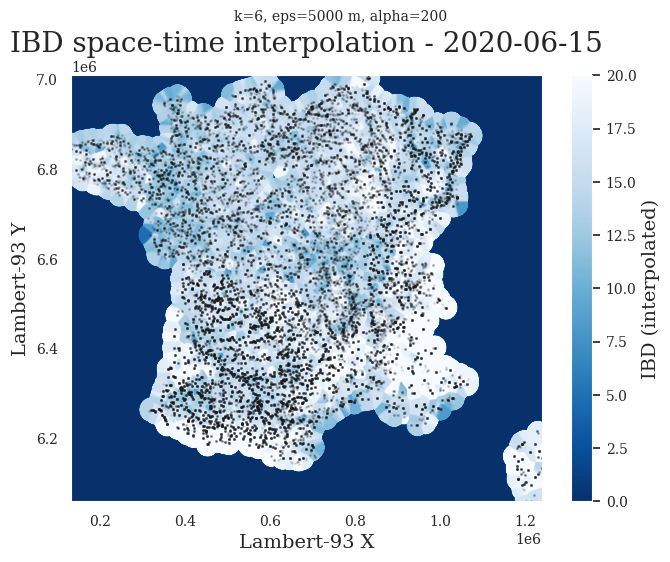

In [64]:
import os
import matplotlib.pyplot as plt

suptitle = f"k={k}, eps={eps} m, alpha={alpha}"

def plot_interpolation(XQ=XQ, YQ=YQ, G=G, x=x, y=y, date_str=date_str, k=k, eps=eps, alpha=alpha):
    os.makedirs("visualizations", exist_ok=True)
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.pcolormesh(XQ, YQ, G, shading='auto', vmin=0, vmax=20, cmap="Blues_r")
    ax.scatter(x, y, c='k', s=1, alpha=0.1)  # station locations
    cbar = fig.colorbar(im, ax=ax, label="IBD (interpolated)")
    title = f"IBD space-time interpolation - {pd.to_datetime(date_str).date()}"
    ax.set_title(title)
    fig.suptitle(suptitle, y=0.94, fontsize=10)
    ax.set_xlabel("Lambert-93 X"); ax.set_ylabel("Lambert-93 Y")
    fig.tight_layout()
    filename = f"visualizations/{date_str}_k{k}_eps{eps}_alpha{alpha}.png"
    fig.savefig(filename, dpi=300)
    plt.show()
    plt.close(fig)
    return fig, ax, im, cbar, filename

fig, ax, im, cbar, filepath = plot_interpolation()

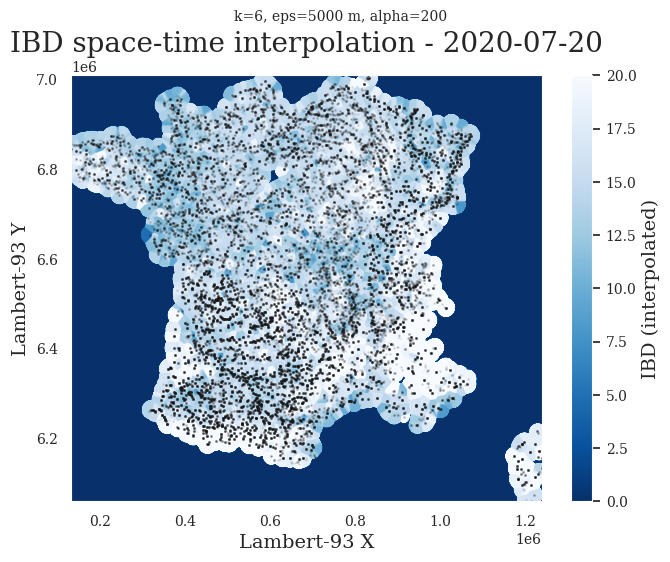

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'IBD space-time interpolation - 2020-07-20'}, xlabel='Lambert-93 X', ylabel='Lambert-93 Y'>,
 'visualizations/2020-07-20_k16_eps4000_alpha120.png')

In [65]:


def get_one_day_plot(date_str, k=64, eps=5000, alpha=alpha):
    tq = _days(date_str)
    XQ, YQ, G = st_predict_grid(x,y,t,z, alpha, xg, yg, tq, k=k, eps=eps)
    fig, ax, im, cbar, filepath = plot_interpolation(XQ=XQ, YQ=YQ, G=G, x=x, y=y, date_str=date_str, k=k, eps=eps, alpha=alpha)
    return fig, ax, im, cbar, filepath

get_one_day_plot(date_str="2020-07-20", k=16, eps=4000, alpha=120)

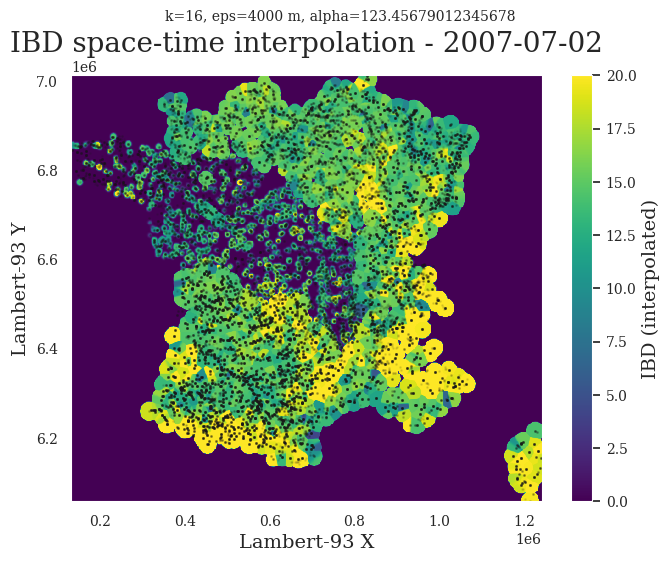

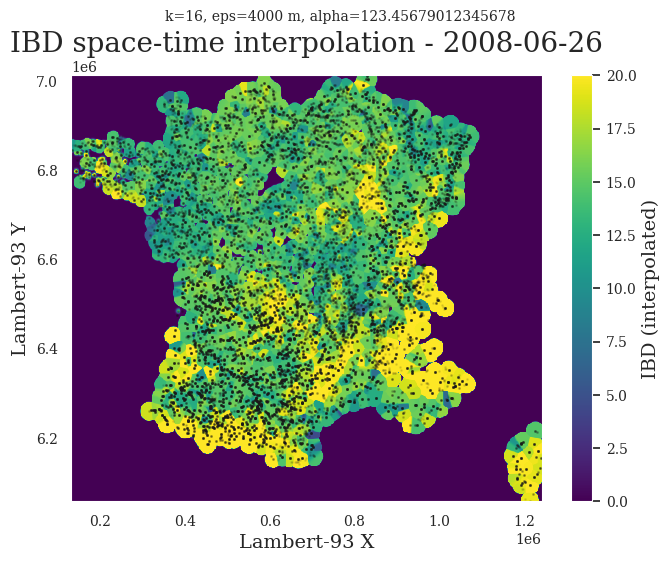

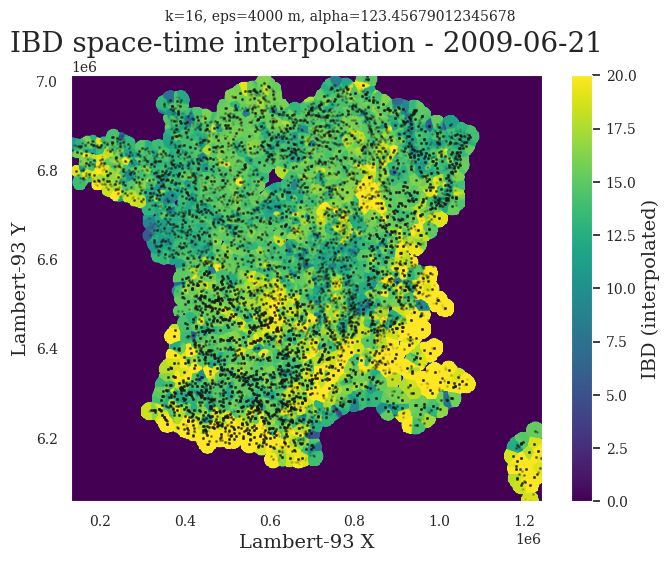

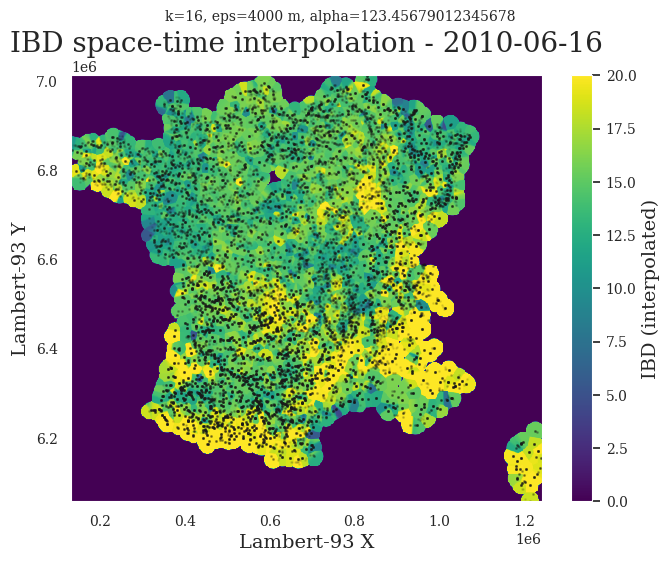

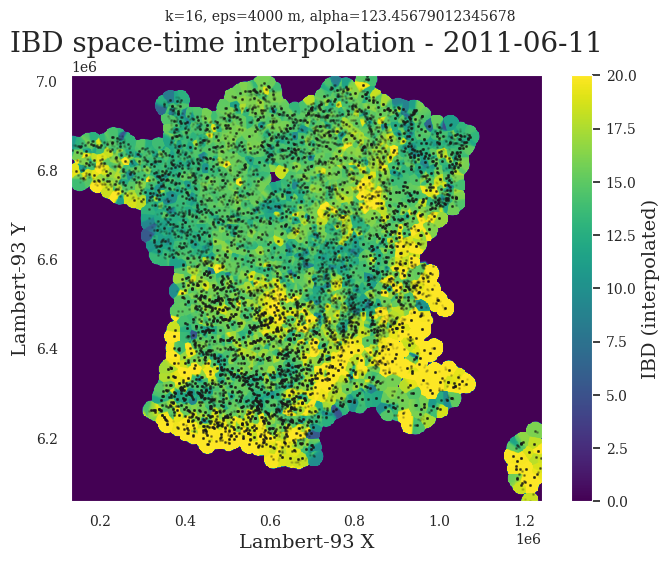

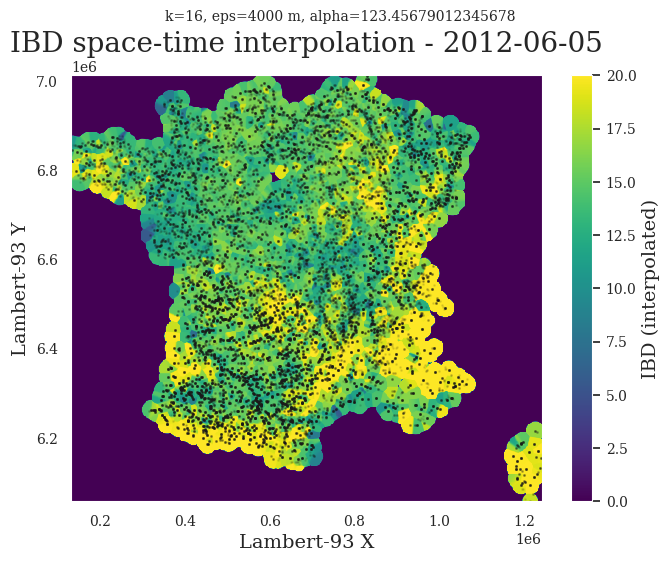

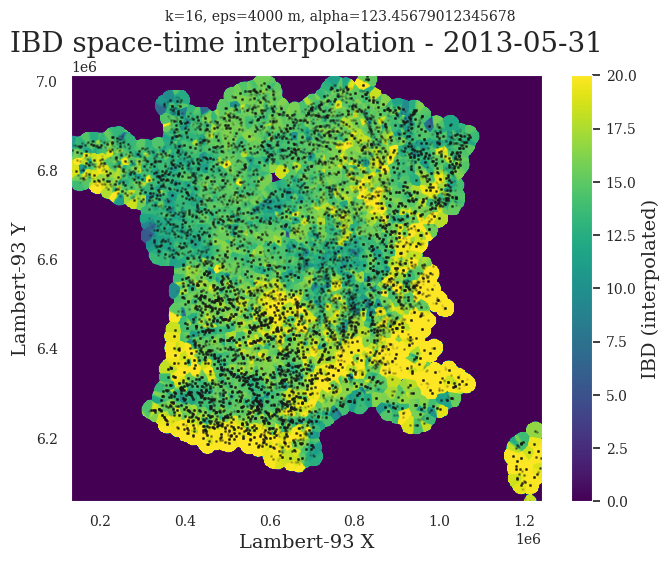

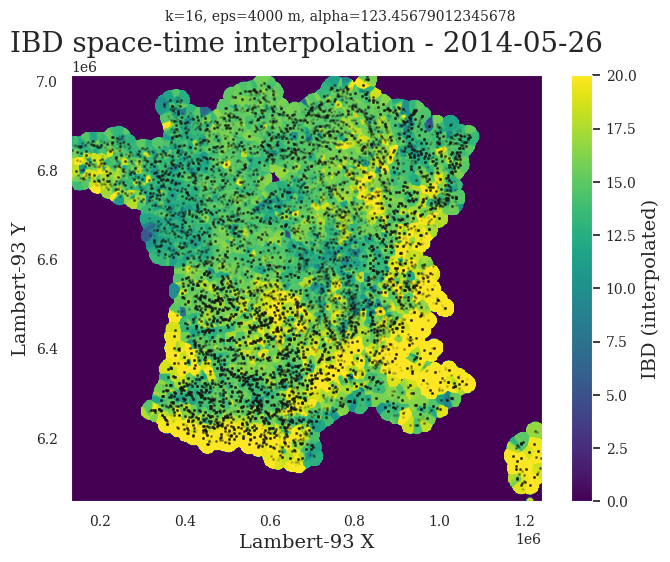

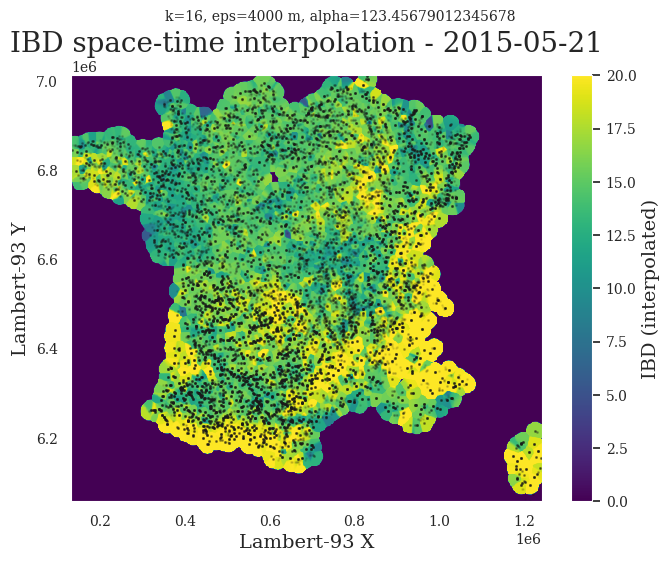

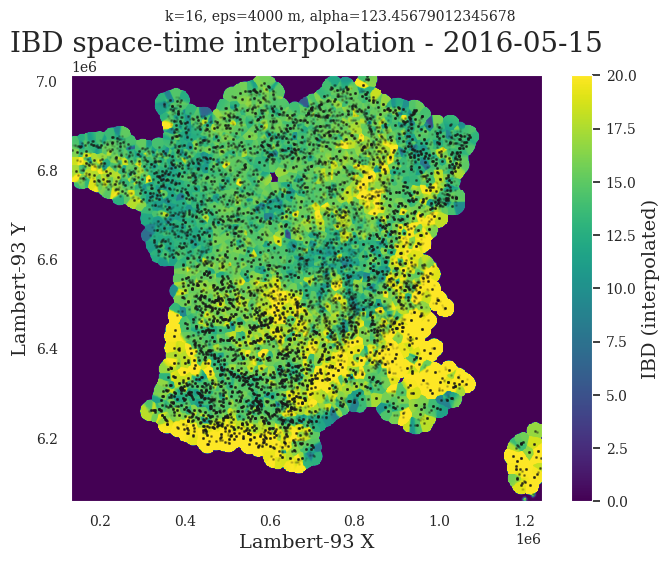

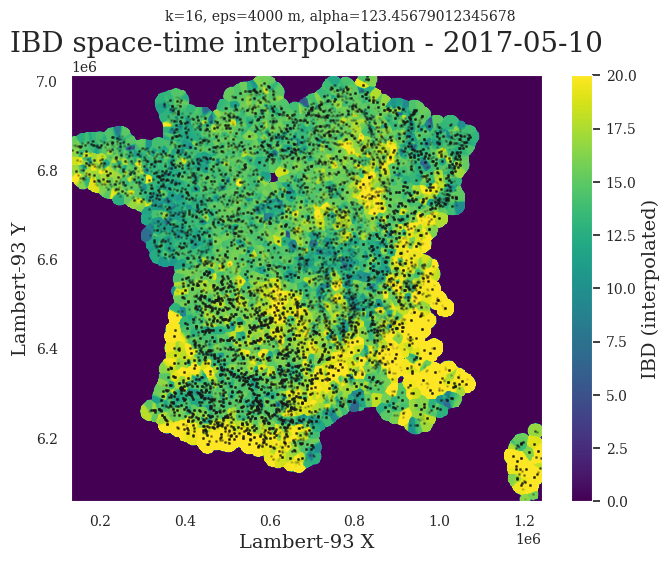

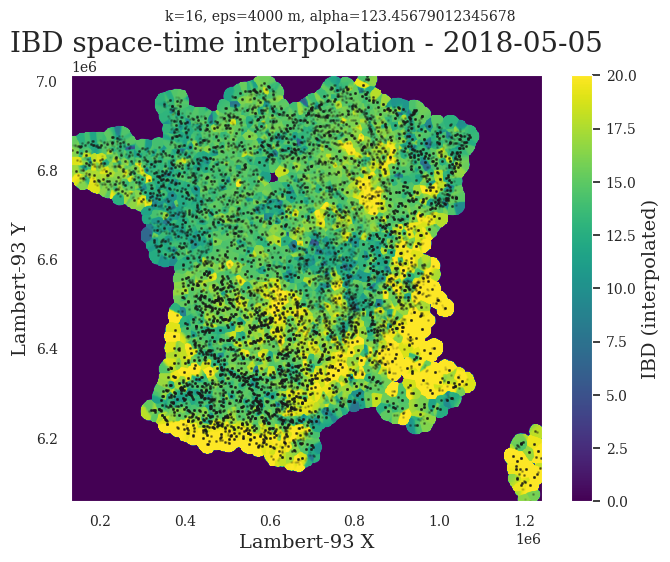

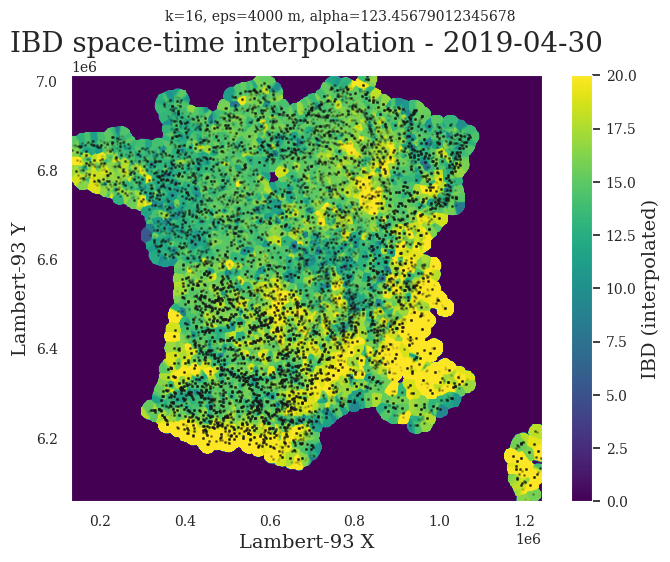

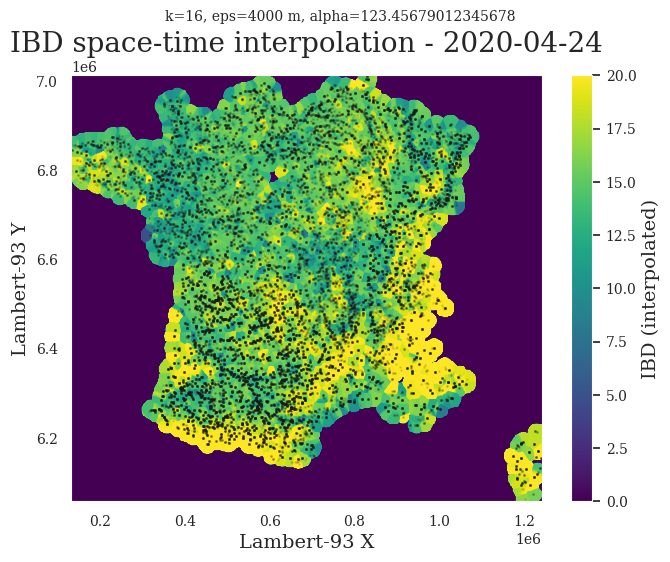

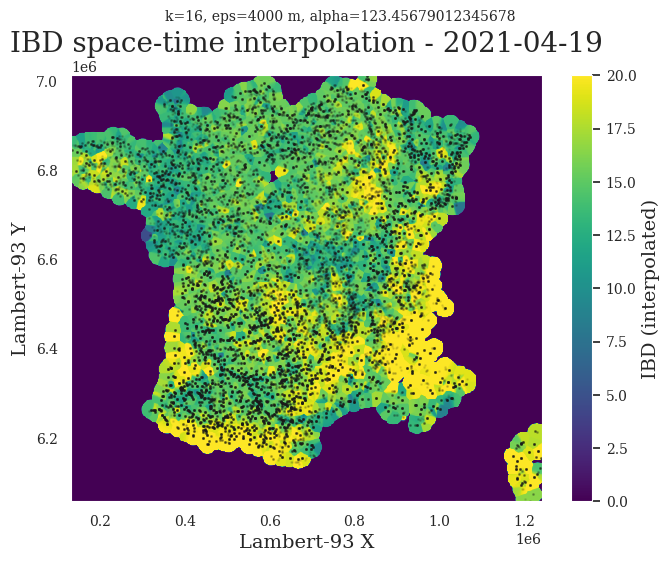

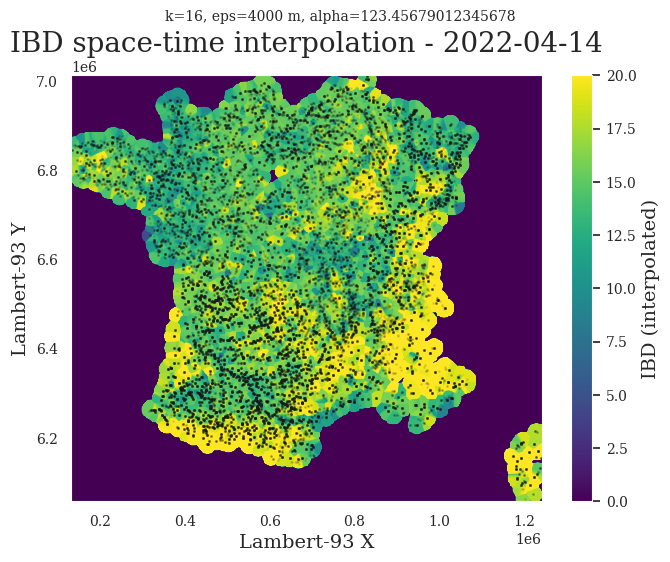

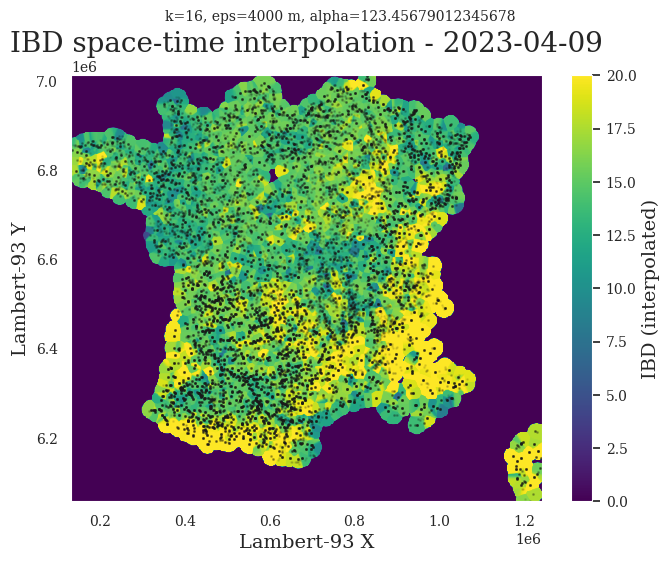

In [ ]:
import imageio

images = []
start = df["Date_SamplingOperation"].min()
end = df["Date_SamplingOperation"].max()
step = pd.Timedelta(days=360)
date_range = pd.date_range(start=start, end=end, freq=step)

k = 16
eps = 4000
alpha = (20000/360/5)**2

for date in date_range:
    fig, ax, im, cbar, filepath = get_one_day_plot(date_str=str(date.date()), k=k, eps=eps, alpha=alpha)
    images.append(imageio.v2.imread(filepath))

imageio.mimsave(f'visualizations/ibd_interpolation_{suptitle}.gif', images, fps=7, loop=0) # loop =0 means infinite loop